In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Load the dataset
# Standard URL for the monthly airline passengers dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Display the first few rows to verify
print(df.head())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


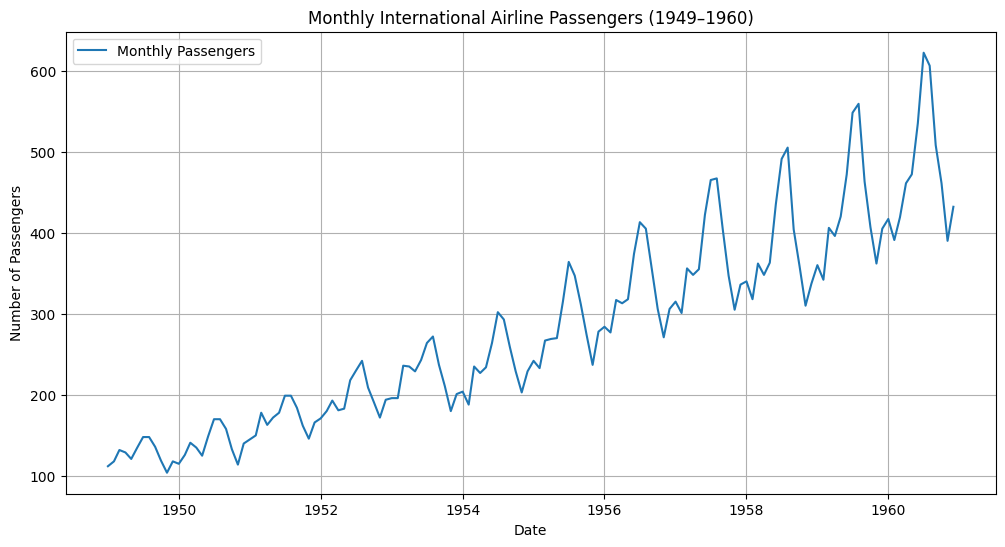

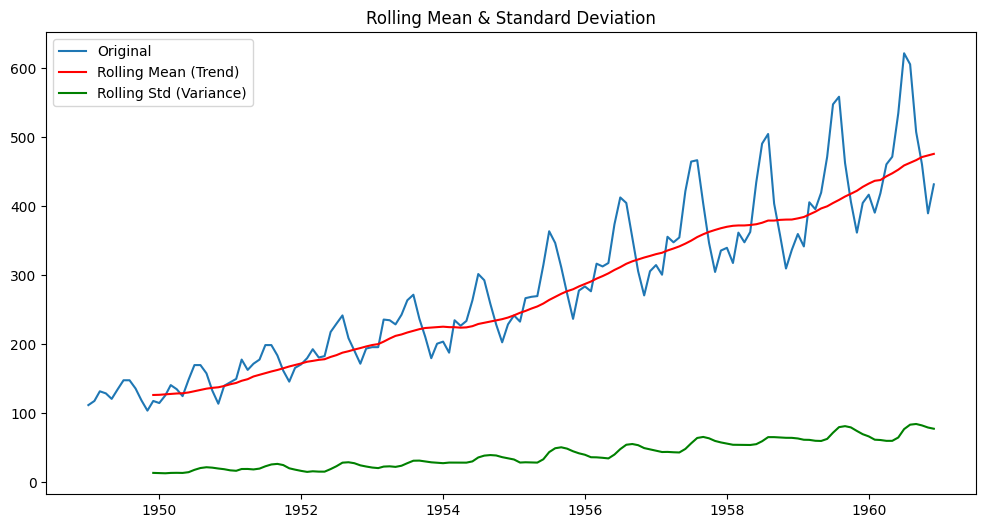

In [10]:
# Task 1: Plot the time series [cite: 9]
plt.figure(figsize=(12, 6))
plt.plot(df['Passengers'], label='Monthly Passengers')
plt.title('Monthly International Airline Passengers (1949–1960)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

# Calculate rolling mean and standard deviation to visualize variance changes
rolling_mean = df['Passengers'].rolling(window=12).mean()
rolling_std = df['Passengers'].rolling(window=12).std()

plt.figure(figsize=(12, 6))
plt.plot(df['Passengers'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean (Trend)', color='red')
plt.plot(rolling_std, label='Rolling Std (Variance)', color='green')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.show()

Augmented Dickey-Fuller Test: Original Series
ADF Test Statistic               0.815369
p-value                          0.991880
# Lags Used                     13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


Augmented Dickey-Fuller Test: 1st Order Differencing
ADF Test Statistic              -2.829267
p-value                          0.054213
# Lags Used                     12.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


Augmented Dickey-Fuller Test: 1st Order + Seasonal Differencing
ADF Test Statistic            -1.559562e+01
p-value                        1.856512e-28
# Lags Used                    0.000000e+00
Number of Observations Used    1.300000e+02
Critical Value (1%)           -3.481682

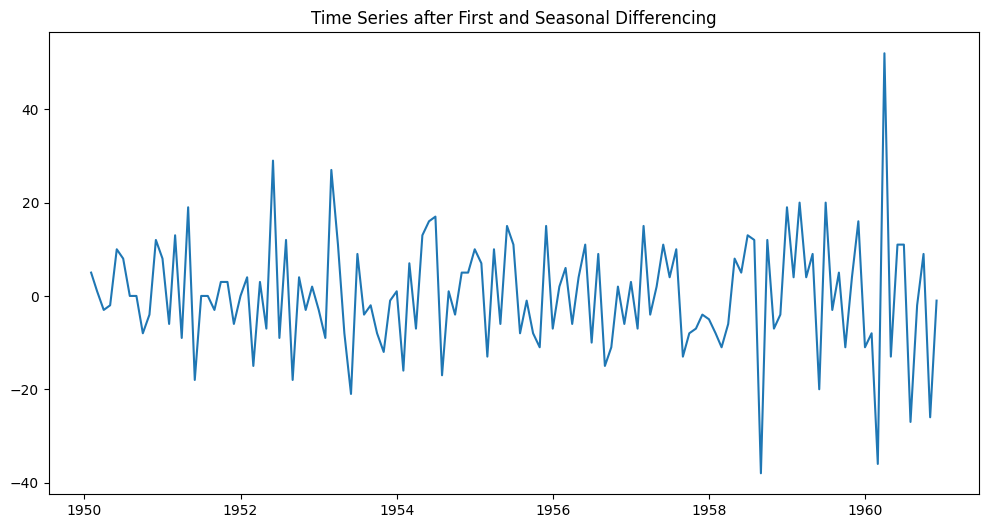

In [11]:
# Task 2: Stationarity Check (ADF Test) [cite: 10]
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna()) # Drop NaN values created by differencing
    labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
    out = pd.Series(result[0:4], index=labels)
    for key, val in result[4].items():
        out[f'Critical Value ({key})'] = val
    print(out)
    print('\n')

# Check original series
adf_test(df['Passengers'], "Original Series")

# Apply First Differencing (d=1) to remove trend
df_diff = df['Passengers'].diff().dropna()
adf_test(df_diff, "1st Order Differencing")

# Apply Seasonal Differencing (D=1, s=12) to remove seasonality [cite: 11]
# Usually required for this specific dataset
df_seasonal_diff = df_diff.diff(12).dropna()
adf_test(df_seasonal_diff, "1st Order + Seasonal Differencing")

# Plot the stationary series
plt.figure(figsize=(12, 6))
plt.plot(df_seasonal_diff)
plt.title('Time Series after First and Seasonal Differencing')
plt.show()

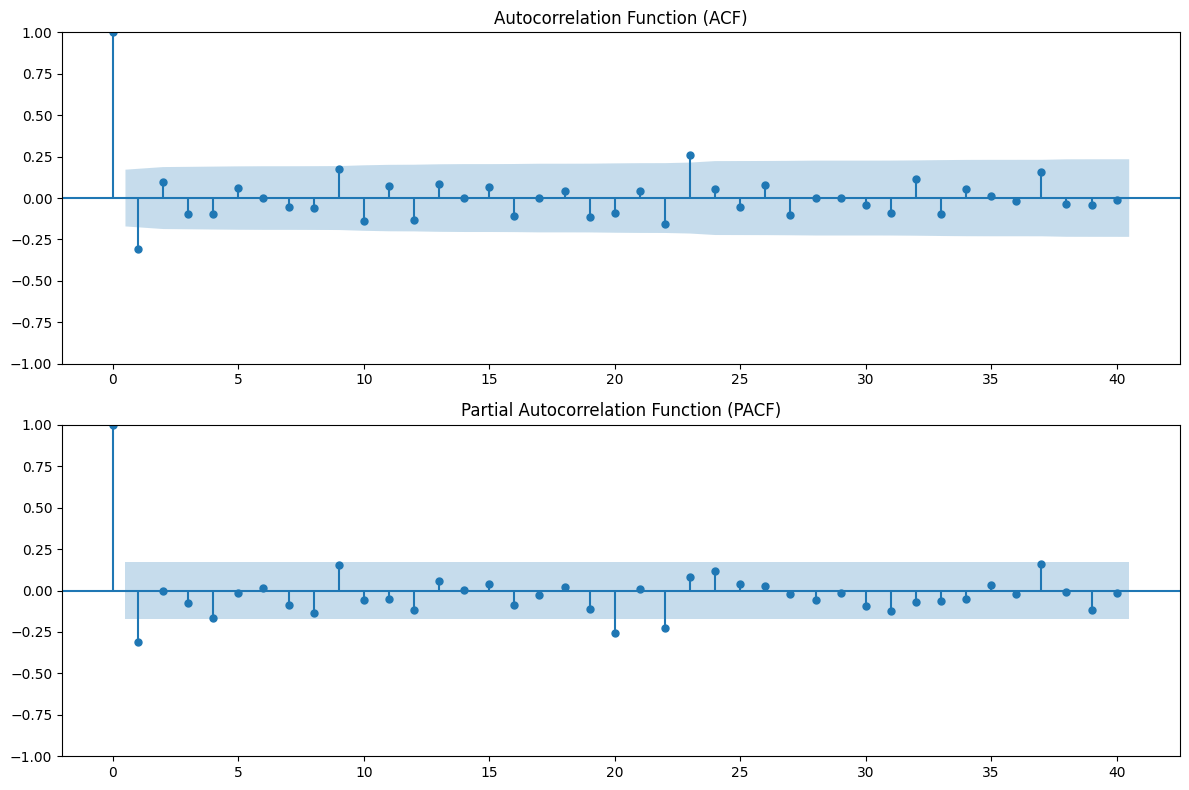

In [18]:
# Task 3: ACF and PACF Plots [cite: 12]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot ACF on the stationary series (df_seasonal_diff)
plot_acf(df_seasonal_diff, lags=40, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# Plot PACF on the stationary series
plot_pacf(df_seasonal_diff, lags=40, ax=ax2, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

Training samples: 120
Testing samples: 24


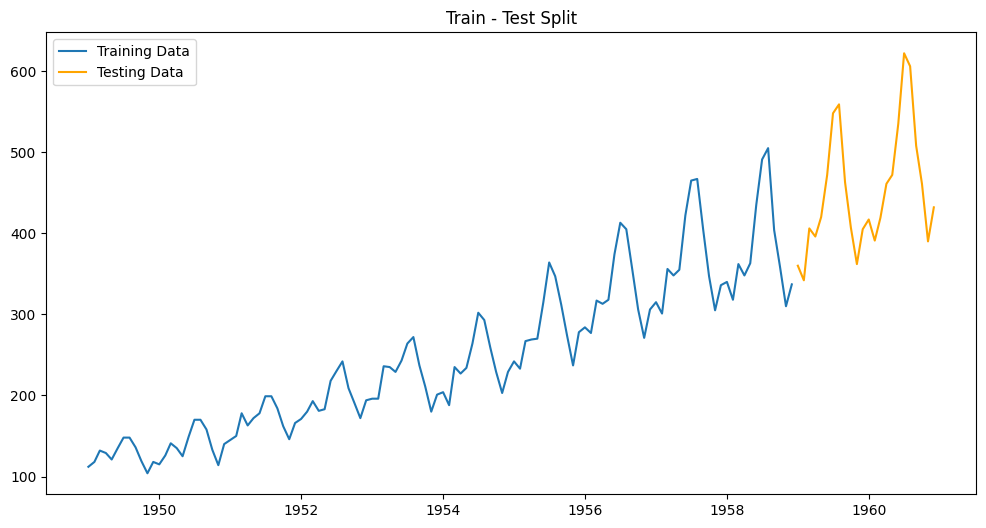

In [13]:
# Task 4: Time-based Train-Test Split [cite: 13]
# We use the last 24 months (2 years) for testing
train_size = len(df) - 24
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Training samples: {len(train)}")
print(f"Testing samples: {len(test)}")

plt.figure(figsize=(12, 6))
plt.plot(train['Passengers'], label='Training Data')
plt.plot(test['Passengers'], label='Testing Data', color='orange')
plt.title('Train - Test Split')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -541.534
Date:                Sun, 11 Jan 2026   AIC                           1093.069
Time:                        12:49:11   BIC                           1106.965
Sample:                    01-01-1949   HQIC                          1098.711
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6570      0.030     55.575      0.000       1.599       1.715
ar.L2         -0.9068      0.027    -33.739      0.000      -0.959      -0.854
ma.L1         -1.8842      0.058    -32.699      0.0

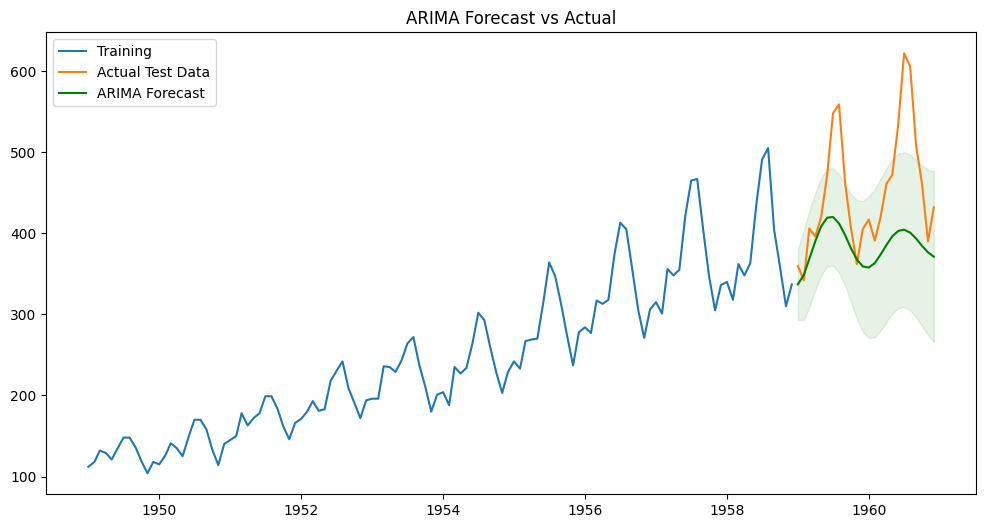

In [14]:
# Task 5: Build ARIMA (p, d, q) [cite: 15]
# Note: Standard ARIMA ignores the seasonal component (s=12).
# Parameters (2,1,2) are placeholders; adjust based on your PACF/ACF observation.
arima_model = ARIMA(train['Passengers'], order=(2, 1, 2))
arima_result = arima_model.fit()

# Report AIC and BIC [cite: 19]
print(arima_result.summary())

# Forecasting [cite: 20]
arima_forecast = arima_result.get_forecast(steps=len(test))
arima_conf_int = arima_forecast.conf_int()
arima_pred = arima_forecast.predicted_mean

# Plot ARIMA Forecast vs Actual
plt.figure(figsize=(12, 6))
plt.plot(train['Passengers'], label='Training')
plt.plot(test['Passengers'], label='Actual Test Data')
plt.plot(test.index, arima_pred, label='ARIMA Forecast', color='green')
plt.fill_between(test.index, arima_conf_int.iloc[:, 0], arima_conf_int.iloc[:, 1], color='green', alpha=0.1)
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                           Passengers   No. Observations:                  120
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -343.463
Date:                              Sun, 11 Jan 2026   AIC                            700.926
Time:                                      12:49:29   BIC                            718.579
Sample:                                  01-01-1949   HQIC                           708.051
                                       - 12-01-1958                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2791      0.573      0.487      0.626      -0.844       1.402
ar.L2          0.46

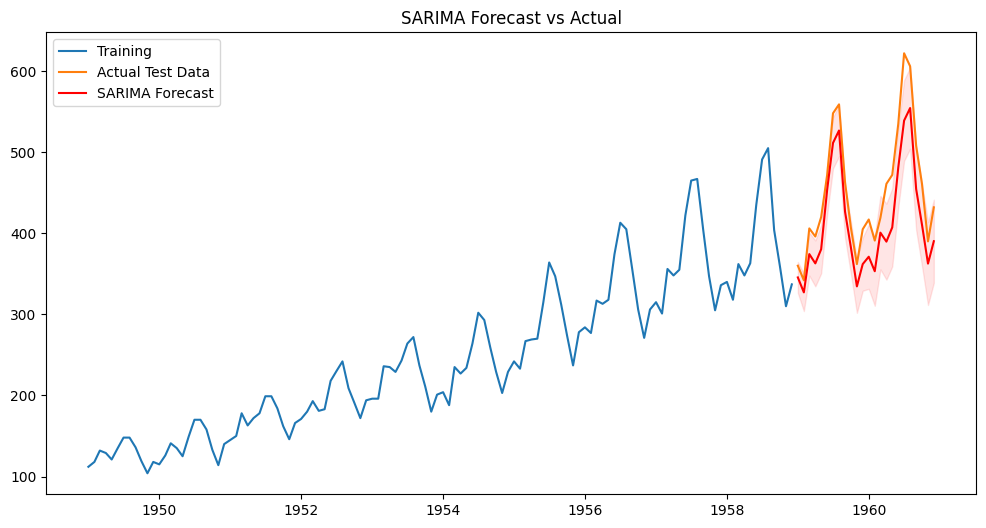

In [15]:
# Task 6: Build SARIMA (p, d, q)(P, D, Q, s) [cite: 21]
# We add the seasonal order (P, D, Q, s). s=12 for monthly data.
sarima_model = SARIMAX(train['Passengers'],
                       order=(2, 1, 2),              # (p, d, q)
                       seasonal_order=(1, 1, 1, 12), # (P, D, Q, s)
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

# Forecasting SARIMA
sarima_forecast = sarima_result.get_forecast(steps=len(test))
sarima_pred = sarima_forecast.predicted_mean
sarima_conf_int = sarima_forecast.conf_int()

# Plot SARIMA Forecast vs Actual [cite: 23]
plt.figure(figsize=(12, 6))
plt.plot(train['Passengers'], label='Training')
plt.plot(test['Passengers'], label='Actual Test Data')
plt.plot(test.index, sarima_pred, label='SARIMA Forecast', color='red')
plt.fill_between(test.index, sarima_conf_int.iloc[:, 0], sarima_conf_int.iloc[:, 1], color='red', alpha=0.1)
plt.title('SARIMA Forecast vs Actual')
plt.legend()
plt.show()

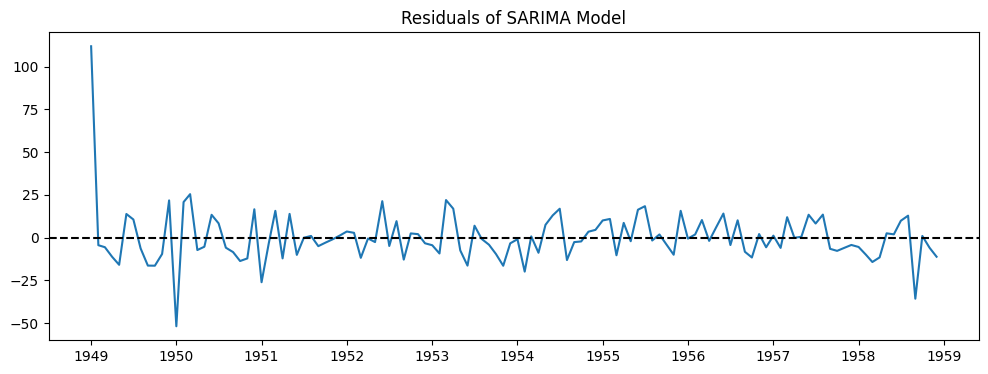

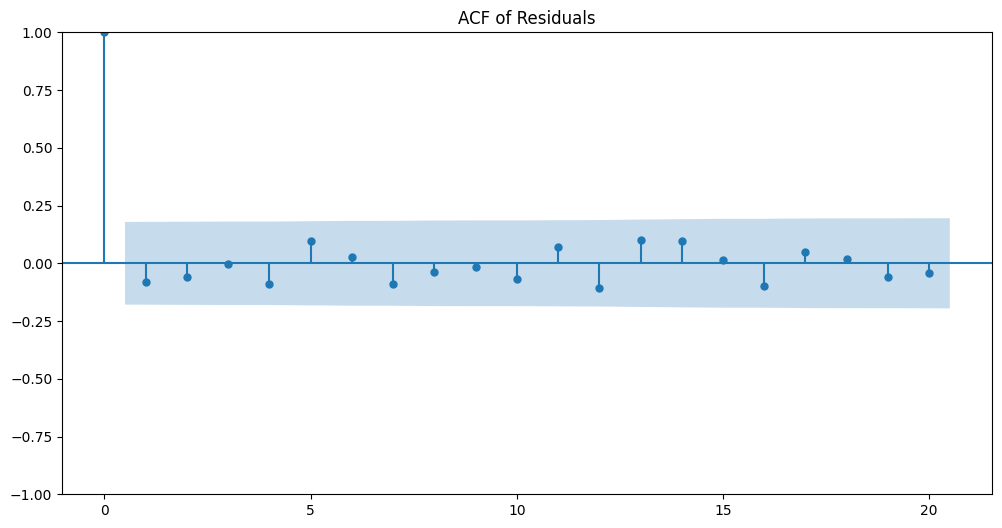

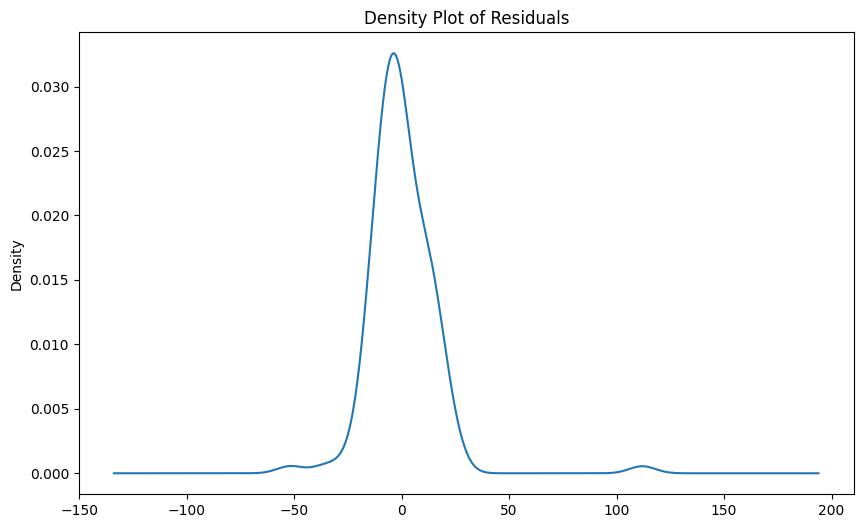

Ljung-Box Test Results (p-value > 0.05 indicates white noise):
     lb_stat  lb_pvalue
10  5.452192      0.859


In [17]:
# Task 7: Residual Analysis (using SARIMA residuals) [cite: 24]
residuals = sarima_result.resid

# 1. Residual Plot
plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.title('Residuals of SARIMA Model')
plt.axhline(0, color='black', linestyle='--')
plt.show()

# 2. ACF of Residuals [cite: 26]
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(residuals, lags=20, ax=ax)
plt.title('ACF of Residuals')
plt.show()

# 3. Density Plot (Histogram) to check normality
plt.figure(figsize=(10, 6))
residuals.plot(kind='kde', title='Density Plot of Residuals')
plt.show()

# Optional: Ljung-Box Test to statistically confirm white noise
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print("Ljung-Box Test Results (p-value > 0.05 indicates white noise):")
print(lb_test)